# 파생변수 v2 — 모달리티 조건부 게이팅 (곱셈 비사용)

**v1 진단:** 26파생 전부 게이트 미달. 원인 = **모달리티 무조건 풀링** — P1(수정률) 등은 신선 IVF에서만 정의인데 전체 풀링→동결·DI에서 NaN(40% 결측). 그 NaN 패턴이 모달리티 플래그와 공선 → 플래그 재인코딩 + 분산만 추가 → 음(−)의 희석.
**v2:** 조건부 게이팅(곱 아님, 유효 부분집합에서만 계산·나머지 NaN) + 누락 모달리티 축(동결 FZ·PGT·자극).
**검증:** §2 교차표(진단) → base / **v1풀링** / **v2게이팅** 동일 ablation 대조(3트리·멀티시드). SHAP·viz 없이 결정 숫자만.

## 0. 준비 + tf_tree + 3트리 인터페이스

In [1]:
import os,glob,re,time
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier
def find_csv(n):
    h=[p for p in glob.glob("/kaggle/input/**/*.csv",recursive=True) if os.path.basename(p)==n]; assert h; return sorted(h,key=len)[0]
train=pd.read_csv(find_csv("train.csv")); TARGET="임신 성공 여부"; ID_COL="ID"
y=train[TARGET].astype(int).values; N=len(train)
def NUM(df,c): return pd.to_numeric(df[c],errors="coerce") if c in df else pd.Series(np.nan,index=df.index)
def DIV(num,den): den=den.astype(float); return num.astype(float)/den.where(den>0)
COL_PROC="특정 시술 유형"; COL_RSN="배아 생성 주요 이유"
NOMINAL_COLS=["시술 시기 코드","시술 유형","배란 유도 유형","난자 출처","정자 출처"]
OCC=["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수","총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
AGE_MAPS={"시술 당시 나이":{"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1},
 "난자 기증자 나이":{"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1},
 "정자 기증자 나이":{"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}}
CMAP={"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
_tp=lambda s: [] if pd.isna(s) else [t.strip() for t in re.split(r"[/:]",str(s)) if t.strip()]
def fit_tree(tr):
    st={}; ig={TARGET,ID_COL}
    st["dead"]=[c for c in tr.columns if c not in ig and tr[c].nunique(dropna=True)<=1]
    st["sparse"]=[c for c in tr.columns if c not in ig and c not in st["dead"] and tr[c].isna().mean()>0.98]
    st["lc"]={c:pd.Index(tr[c].astype("category").cat.categories) for c in NOMINAL_COLS if c in tr}
    st["pv"]=sorted({t for L in tr[COL_PROC].apply(_tp) for t in L}); return st
def tf_tree(df,st):
    df=df.copy()
    if TARGET in df: df=df.drop(columns=[TARGET])
    df["is_DI"]=(df["시술 유형"]=="DI").astype(int)
    df=df.drop(columns=[c for c in st["dead"] if c in df.columns])
    for c in st["sparse"]:
        if c in df: df[f"{c}_있음"]=df[c].notna().astype(int); df=df.drop(columns=[c])
    for c in OCC:
        if c in df: df[c]=df[c].astype(object).map(CMAP)
    for c,m in AGE_MAPS.items():
        if c in df: df[c]=df[c].astype(object).map(m)
    cats=[]
    for c,cc in st["lc"].items():
        if c in df: df[c]=pd.Categorical(df[c],categories=cc).codes.astype("int32"); cats.append(c)
    ts=df[COL_PROC].apply(_tp)
    for v in st["pv"]: df[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
    df=df.drop(columns=[c for c in [COL_PROC,COL_RSN,ID_COL] if c in df.columns])
    obj=[c for c in df.columns if df[c].dtype==object]
    if obj: df=df.drop(columns=obj)
    for c in cats: df[c]=df[c].fillna(-1).astype("int32")
    return df,[c for c in cats if c in df.columns]
st=fit_tree(train); Xb,CATF=tf_tree(train,st)
KINDS=["lgb","xgb","cat"]; KNAME={"lgb":"LightGBM","xgb":"XGBoost","cat":"CatBoost"}
LGP=dict(objective="binary",metric="auc",verbose=-1,learning_rate=0.05,num_leaves=63,feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,min_child_samples=50)
XGP=dict(objective="binary:logistic",eval_metric="auc",tree_method="hist",learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8)
def fit_one(kind,Xt,yt,Xv,yv,catf,seed):
    if kind=="lgb": return lgb.train(dict(LGP,seed=seed),lgb.Dataset(Xt,yt,categorical_feature=catf),1500,valid_sets=[lgb.Dataset(Xv,yv,categorical_feature=catf)],callbacks=[lgb.early_stopping(80,verbose=False),lgb.log_evaluation(0)])
    if kind=="xgb": return xgb.train(dict(XGP,seed=seed),xgb.DMatrix(Xt.values,label=yt),1500,evals=[(xgb.DMatrix(Xv.values,label=yv),"v")],early_stopping_rounds=80,verbose_eval=False)
    m=CatBoostClassifier(iterations=1500,learning_rate=0.05,depth=6,verbose=0,random_seed=seed,early_stopping_rounds=80); m.fit(Xt,yt,eval_set=(Xv,yv),cat_features=catf); return m
def pred_one(kind,m,X):
    if kind=="lgb": return m.predict(X)
    if kind=="xgb": return m.predict(xgb.DMatrix(X.values),iteration_range=(0,m.best_iteration+1))
    return m.predict_proba(X)[:,1]
def oof(kind,X,seed,nf=3):
    o=np.zeros(N); catf=[c for c in CATF if c in X.columns]
    for tri,vai in StratifiedKFold(nf,shuffle=True,random_state=seed).split(X,y):
        m=fit_one(kind,X.iloc[tri],y[tri],X.iloc[vai],y[vai],catf,seed); o[vai]=pred_one(kind,m,X.iloc[vai])
    return roc_auc_score(y,o)
# 시각화용: matplotlib(인라인 — Agg 안 씀!)·shap·한글폰트
import subprocess; subprocess.run("pip install -q shap",shell=True); subprocess.run("apt-get -qq install -y fonts-nanum >/dev/null 2>&1",shell=True)
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
for fp in glob.glob("/usr/share/fonts/truetype/nanum/*.ttf"):
    try: fm.fontManager.addfont(fp)
    except: pass
try: plt.rcParams["font.family"]="NanumGothic"
except: pass
plt.rcParams["axes.unicode_minus"]=False   # Agg 미사용 → plt.show()가 셀에 인라인 렌더
def shap_one(kind,m,X,catf):
    import xgboost as xgb
    if kind=="lgb": cc=m.predict(X,pred_contrib=True)
    elif kind=="xgb": cc=m.predict(xgb.DMatrix(X.values),pred_contribs=True)
    else:
        from catboost import Pool; cc=m.get_feature_importance(Pool(X,cat_features=catf),type="ShapValues")
    return cc[:,:-1], float(cc[0,-1])
print("tf_tree",Xb.shape,"| 3트리 + 시각화(인라인) 준비")

tf_tree (256351, 72) | 3트리 + 시각화(인라인) 준비


## 1. 모달리티 마스크 + v1 풀링 비율 + v2 게이팅 파생

In [2]:
def masks(df):
    return {"신선":NUM(df,"신선 배아 사용 여부")==1,"동결":NUM(df,"동결 배아 사용 여부")==1,
            "기증배아":NUM(df,"기증 배아 사용 여부")==1,"DI":(df["시술 유형"].astype(str)=="DI"),
            "ICSI":NUM(df,"미세주입된 난자 수")>0,
            "본인난자":df["난자 출처"].astype(str)=="본인 제공","기증난자":df["난자 출처"].astype(str)=="기증 제공"}
def v1_ratios(df):
    return {"P1":DIV(NUM(df,"총 생성 배아 수"),NUM(df,"혼합된 난자 수")),
            "P2":DIV(NUM(df,"미세주입에서 생성된 배아 수"),NUM(df,"미세주입된 난자 수")),
            "P6":DIV(NUM(df,"총 생성 배아 수"),NUM(df,"수집된 신선 난자 수")),
            "L3":NUM(df,"배아 이식 경과일")-NUM(df,"난자 혼합 경과일"),
            "L6":DIV(NUM(df,"총 생성 배아 수"),NUM(df,"미세주입된 난자 수"))}
def build_v1_pooled(df): return pd.DataFrame(v1_ratios(df),index=df.index)
def build_v2_gated(df):
    M=masks(df); r=v1_ratios(df); F={}
    # 게이팅: 유효 부분집합에서만(나머지 NaN) — 곱 아님
    F["g신선_수정률"]=r["P1"].where(M["신선"])
    F["gICSI_수정효율"]=r["P2"].where(M["ICSI"])
    F["g본인_난자수율"]=r["P6"].where(M["본인난자"])
    F["g기증_난자수율"]=r["P6"].where(M["기증난자"])
    F["g신선_배양일수"]=r["L3"].where(M["신선"])
    # 동결 사이클 전용(신선 비율이 NaN인 자리)
    F["FZ1_동결해동이식간격"]=(NUM(df,"배아 이식 경과일")-NUM(df,"배아 해동 경과일")).where(M["동결"])
    F["FZ2_해동이식률"]=DIV(NUM(df,"이식된 배아 수"),NUM(df,"해동된 배아 수"))
    F["FZ3_해동난자수율"]=DIV(NUM(df,"총 생성 배아 수"),NUM(df,"해동 난자 수"))
    # PGT 축(희소) + 자극 축
    F["PG1_PGT강도"]=NUM(df,"착상 전 유전 검사 사용 여부").fillna(0)+NUM(df,"착상 전 유전 진단 사용 여부").fillna(0)
    F["PG2_PGT분류"]=NUM(df,"PGD 시술 여부").fillna(0)+NUM(df,"PGS 시술 여부").fillna(0)
    F["ST1_자극"]=NUM(df,"배란 자극 여부").fillna(0)
    return pd.DataFrame(F,index=df.index)
V1=build_v1_pooled(train); V2=build_v2_gated(train)
print("v1 풀링",V1.shape[1],"개 | v2 게이팅+신규",V2.shape[1],"개")
print("v1 평균결측 %.0f%% | v2 평균결측 %.0f%%"%(V1.isna().mean().mean()*100,V2.isna().mean().mean()*100))

v1 풀링 5 개 | v2 게이팅+신규 11 개
v1 평균결측 36% | v2 평균결측 45%


## 2. ★진단 — 모달리티 × v1비율 NaN율 교차표 (풀링 문제 입증)

In [3]:
M=masks(train); r=v1_ratios(train)
rows=[]
for mn,mask in M.items():
    sub={"모달리티":f"{mn}({int(mask.sum())})"}
    for rn,rv in r.items(): sub[rn]=f"{rv[mask].isna().mean()*100:.0f}%"
    rows.append(sub)
ct=pd.DataFrame(rows).set_index("모달리티")
print("각 모달리티 부분집합에서 v1 비율의 NaN율:")
print(ct.to_string())
print("\n→ P1/P2/L3/L6가 동결·DI에서 ~100% NaN = 신선 IVF에서만 정의.")
print("  즉 풀링 컬럼의 NaN 패턴 = 모달리티 플래그와 공선(트리가 이미 가진 정보). 게이팅이 이걸 분리.")

각 모달리티 부분집합에서 v1 비율의 NaN율:
                P1    P2    P6    L3    L6
모달리티                                      
신선(210136)      3%   42%    7%   16%   42%
동결(40126)      99%   99%   99%   99%   99%
기증배아(2458)     40%   72%  100%   45%   72%
DI(6291)      100%  100%  100%  100%  100%
ICSI(122391)    0%    0%    5%   14%    0%
본인난자(234291)   18%   50%   16%   29%   50%
기증난자(15769)    31%   62%  100%   39%   62%

→ P1/P2/L3/L6가 동결·DI에서 ~100% NaN = 신선 IVF에서만 정의.
  즉 풀링 컬럼의 NaN 패턴 = 모달리티 플래그와 공선(트리가 이미 가진 정보). 게이팅이 이걸 분리.


## 3. ★대조 ablation — base / v1풀링 / v2게이팅 (3트리·멀티시드)

In [4]:
SEEDS=(42,7,2024)
Xv1=pd.concat([Xb.reset_index(drop=True),V1.reset_index(drop=True)],axis=1)
Xv2=pd.concat([Xb.reset_index(drop=True),V2.reset_index(drop=True)],axis=1)
res={}
for k in KINDS:
    base={s:oof(k,Xb,s) for s in SEEDS}
    d1=[oof(k,Xv1,s)-base[s] for s in SEEDS]; d2=[oof(k,Xv2,s)-base[s] for s in SEEDS]
    res[k]=dict(v1=(float(np.mean(d1)),float(np.std(d1))),v2=(float(np.mean(d2)),float(np.std(d2))))
    g=lambda mu,sd:'✅통과' if abs(mu)>sd and mu>0.0002 else '❌노이즈'
    print(f"{KNAME[k]:9s}: v1풀링 Δ={np.mean(d1):+.5f}±{np.std(d1):.5f} {g(np.mean(d1),np.std(d1))}  |  v2게이팅 Δ={np.mean(d2):+.5f}±{np.std(d2):.5f} {g(np.mean(d2),np.std(d2))}")

LightGBM : v1풀링 Δ=-0.00041±0.00011 ❌노이즈  |  v2게이팅 Δ=-0.00014±0.00009 ❌노이즈
XGBoost  : v1풀링 Δ=-0.00025±0.00013 ❌노이즈  |  v2게이팅 Δ=+0.00007±0.00009 ❌노이즈
CatBoost : v1풀링 Δ=-0.00009±0.00005 ❌노이즈  |  v2게이팅 Δ=+0.00033±0.00001 ✅통과


## 4. 판정

In [5]:
import json
print("=== v1풀링 vs v2게이팅 (트리별 Δ) ===")
print(f"{'tree':9s} | {'v1풀링':>10s} | {'v2게이팅':>10s} | 개선?")
improved=False; v2pass=False
for k in KINDS:
    m1=res[k]['v1'][0]; m2=res[k]['v2'][0]; up=m2>m1
    improved=improved or up
    if abs(m2)>res[k]['v2'][1] and m2>0.0002: v2pass=True
    print(f"{KNAME[k]:9s} | {m1:+.5f} | {m2:+.5f} | {'↑' if up else '—'}")
print("\n판정:")
if v2pass:
    print(" ✅ v2 게이팅이 게이트 통과 — 조건부-해석 가설 확정. 통과 파생 → 블렌드 증분으로.")
elif improved:
    print(" 🟡 게이팅이 풀링보다 낫지만 아직 게이트 미달 — 방향 맞음, 세그먼트 분리/타깃정의 축으로.")
else:
    print(" ❌ 게이팅도 노이즈 — 'raw+모달리티 플래그가 이미 충분' 천장 서사 강화(발표 자산).")
json.dump(res,open("/kaggle/working/v2_gating_compare.json","w"))
# 게이팅이 통과/개선이면 v2 파생 저장(블렌드 증분 재사용)
if v2pass or improved:
    V2.to_csv("/kaggle/working/deriv_v2_gated.csv",index=False); print("💾 deriv_v2_gated.csv 저장")
print("💾 v2_gating_compare.json 저장")

=== v1풀링 vs v2게이팅 (트리별 Δ) ===
tree      |       v1풀링 |      v2게이팅 | 개선?
LightGBM  | -0.00041 | -0.00014 | ↑
XGBoost   | -0.00025 | +0.00007 | ↑
CatBoost  | -0.00009 | +0.00033 | ↑

판정:
 ✅ v2 게이팅이 게이트 통과 — 조건부-해석 가설 확정. 통과 파생 → 블렌드 증분으로.
💾 deriv_v2_gated.csv 저장
💾 v2_gating_compare.json 저장


---
# 📊 이하 시각화 (결정은 §2~4에서 끝·저장됨 — 아래가 다 죽어도 안전)
Agg 안 써서 `plt.show()`가 셀에 인라인 렌더. 전부 try/except 격리. 3트리.

## 5. v1풀링 vs v2게이팅 Δ — 트리별 막대

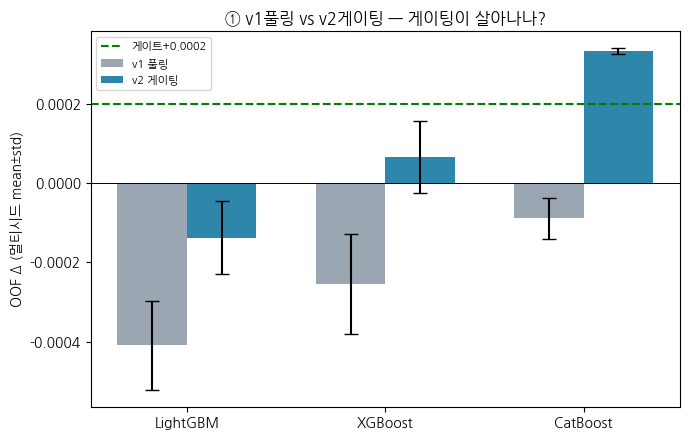

In [6]:
try:
    x=np.arange(len(KINDS)); w=0.35
    plt.figure(figsize=(7,4.5))
    plt.bar(x-w/2,[res[k]["v1"][0] for k in KINDS],w,yerr=[res[k]["v1"][1] for k in KINDS],capsize=5,label="v1 풀링",color="#9aa6b2")
    plt.bar(x+w/2,[res[k]["v2"][0] for k in KINDS],w,yerr=[res[k]["v2"][1] for k in KINDS],capsize=5,label="v2 게이팅",color="#2e86ab")
    plt.axhline(0.0002,color="g",ls="--",label="게이트+0.0002"); plt.axhline(0,color="k",lw=.7)
    plt.xticks(x,[KNAME[k] for k in KINDS]); plt.ylabel("OOF Δ (멀티시드 mean±std)")
    plt.title("① v1풀링 vs v2게이팅 — 게이팅이 살아나나?"); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("/kaggle/working/v2viz1_delta.png",dpi=110); plt.show()
except Exception as e: print("⚠️ Δ막대 skip:",type(e).__name__,e)

## 6. 3트리 SHAP — v2 피처가 어떻게 쓰이나 (②)

  LightGBM: SHAP (12000, 83) (23s)
  XGBoost: SHAP (12000, 83) (27s)
  CatBoost: SHAP (12000, 83) (105s)


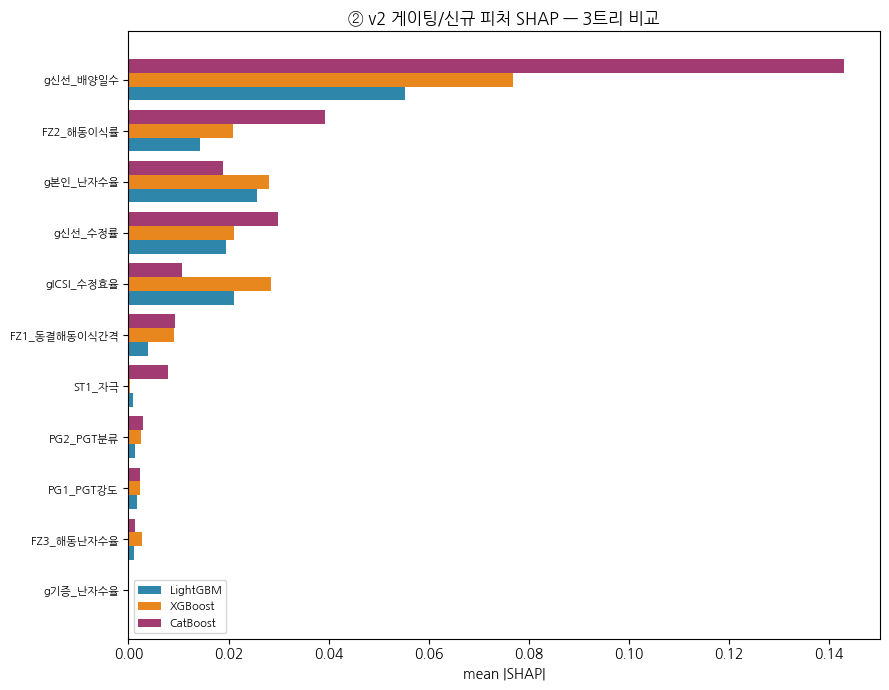

트리별 top3 v2피처: {'LightGBM': ['g신선_배양일수', 'g본인_난자수율', 'gICSI_수정효율'], 'XGBoost': ['g신선_배양일수', 'gICSI_수정효율', 'g본인_난자수율'], 'CatBoost': ['g신선_배양일수', 'FZ2_해동이식률', 'g신선_수정률']}


In [7]:
SH=None; V2COLS=list(V2.columns)
try:
    import shap
    tri,vai=next(iter(StratifiedKFold(5,shuffle=True,random_state=42).split(Xv2,y)))
    catf=[c for c in CATF if c in Xv2.columns]
    rng=np.random.default_rng(42); samp=rng.choice(vai,size=min(12000,len(vai)),replace=False)
    Xs=Xv2.iloc[samp].reset_index(drop=True); SH={}
    for k in KINDS:
        t0=time.time(); m=fit_one(k,Xv2.iloc[tri],y[tri],Xv2.iloc[vai],y[vai],catf,42)
        sv,base=shap_one(k,m,Xs,catf); SH[k]=dict(sv=sv,base=base,proba=pred_one(k,m,Xs))
        print(f"  {KNAME[k]}: SHAP {sv.shape} ({time.time()-t0:.0f}s)")
    imp3=pd.DataFrame({k:pd.Series(np.abs(SH[k]["sv"]).mean(0),index=Xv2.columns)[V2COLS] for k in KINDS})
    order=imp3.mean(1).sort_values(ascending=False).index[::-1]
    x=np.arange(len(order)); w=0.27; plt.figure(figsize=(9,7))
    for j,k in enumerate(KINDS): plt.barh(x+(j-1)*w,imp3[k].reindex(order).values,w,label=KNAME[k],color=["#2e86ab","#e8871e","#a23b72"][j])
    plt.yticks(x,order,fontsize=8); plt.xlabel("mean |SHAP|"); plt.legend(fontsize=8)
    plt.title("② v2 게이팅/신규 피처 SHAP — 3트리 비교"); plt.tight_layout(); plt.savefig("/kaggle/working/v2viz2_shap.png",dpi=110); plt.show()
    print("트리별 top3 v2피처:",{KNAME[k]:list(imp3[k].sort_values(ascending=False).head(3).index) for k in KINDS})
except Exception as e: print("⚠️ SHAP skip(결정 무관):",type(e).__name__,e); SH=None

## 7. SHAP beeswarm — 트리별 (③)

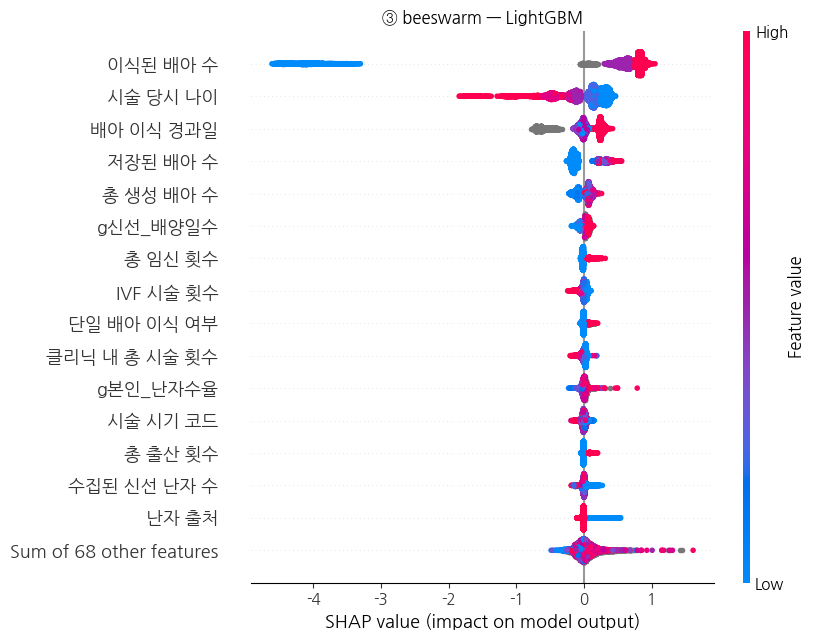

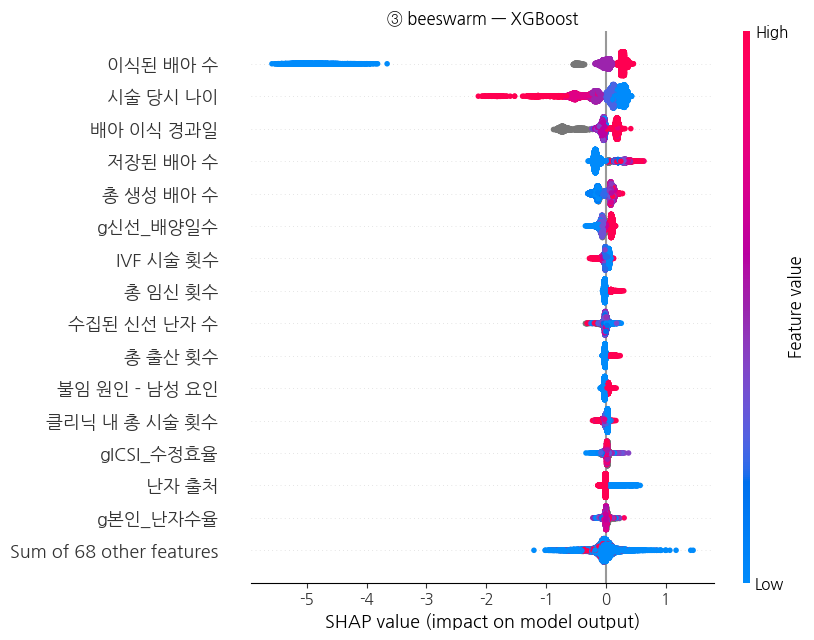

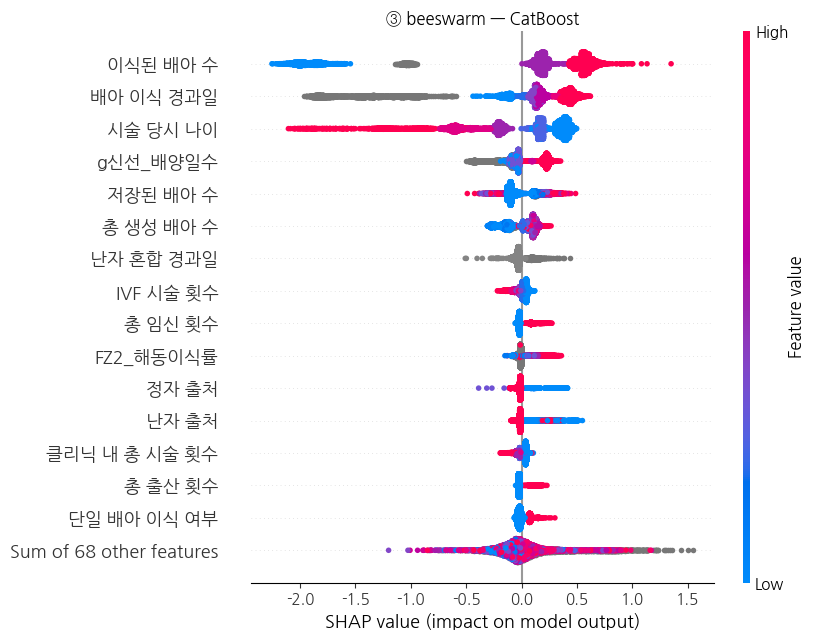

In [8]:
try:
    assert SH; import shap
    for k in KINDS:
        e=shap.Explanation(values=SH[k]["sv"],base_values=np.full(len(Xs),SH[k]["base"]),data=Xs.values,feature_names=list(Xv2.columns))
        shap.plots.beeswarm(e,max_display=16,show=False)
        fig=plt.gcf(); fig.set_size_inches(8.5,6.5); plt.title(f"③ beeswarm — {KNAME[k]}")
        plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz3_bee_{k}.png",dpi=110,bbox_inches="tight"); plt.show(); plt.close()
except Exception as e: print("⚠️ beeswarm skip:",type(e).__name__,e)

## 8. ★ Waterfall — 동일 케이스를 3트리가 어떻게 (④)

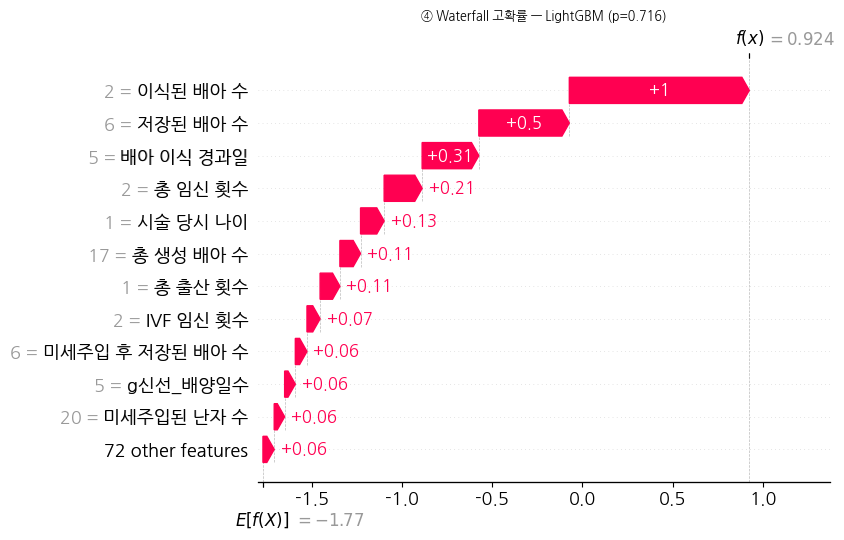

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_58/2438656281.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


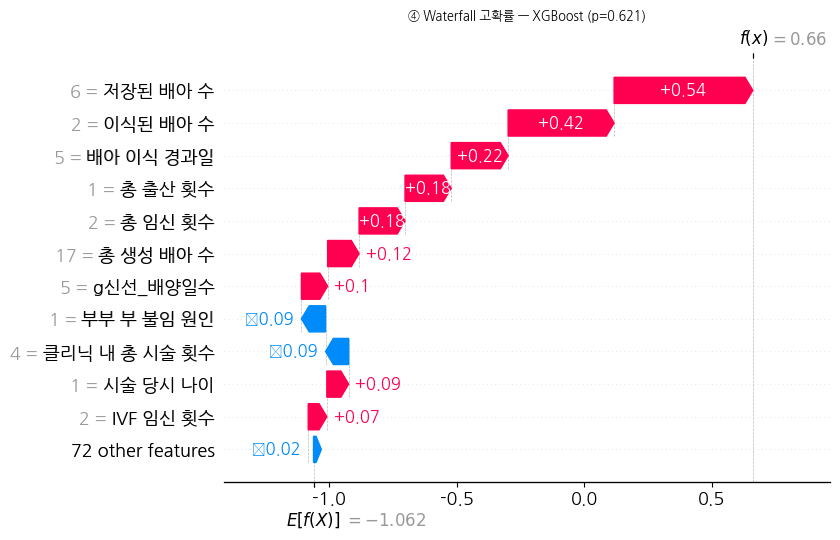

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_58/2438656281.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


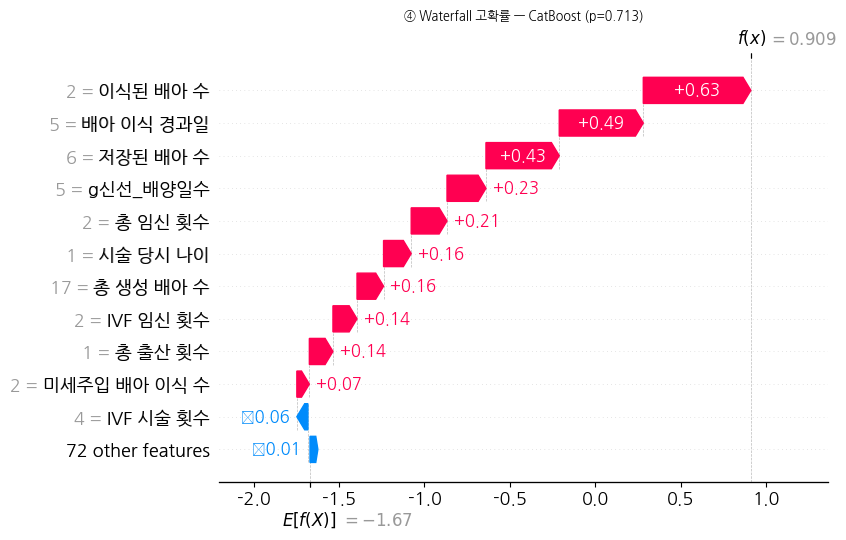

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)


[고확률] v2피처 기여: {'LightGBM': {'g신선_배양일수': np.float64(0.059), 'gICSI_수정효율': np.float64(0.021), 'g본인_난자수율': np.float64(0.014)}, 'XGBoost': {'g신선_배양일수': np.float32(0.103), 'gICSI_수정효율': np.float32(0.052), 'g신선_수정률': np.float32(0.028)}, 'CatBoost': {'g신선_배양일수': np.float64(0.228), 'g신선_수정률': np.float64(0.048), 'gICSI_수정효율': np.float64(0.041)}}


/tmp/ipykernel_58/2438656281.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


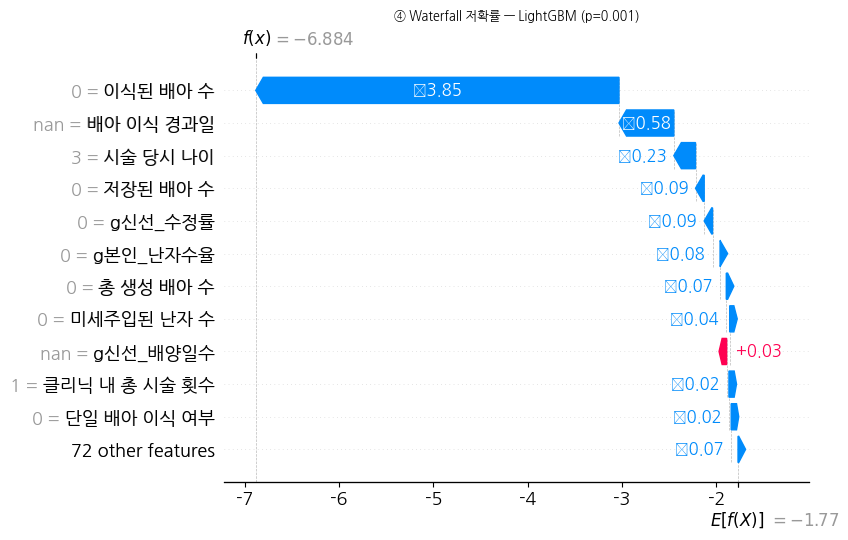

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_58/2438656281.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


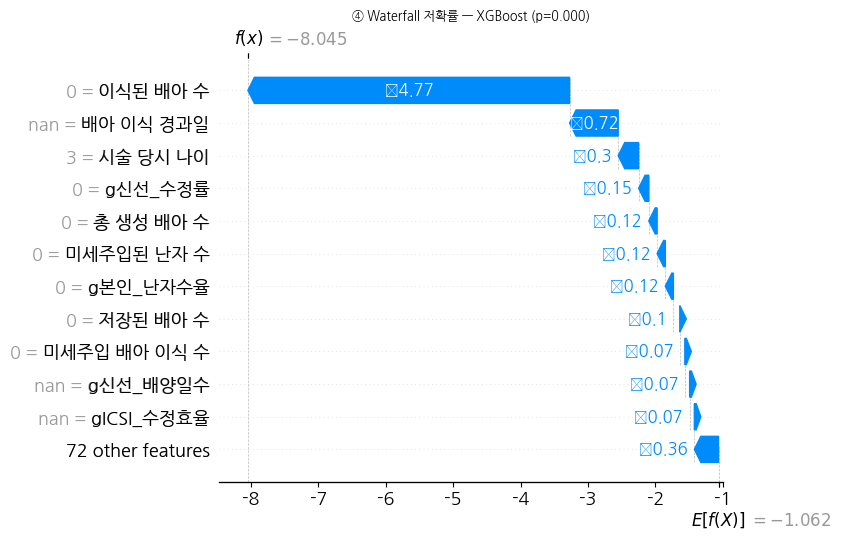

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_58/2438656281.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


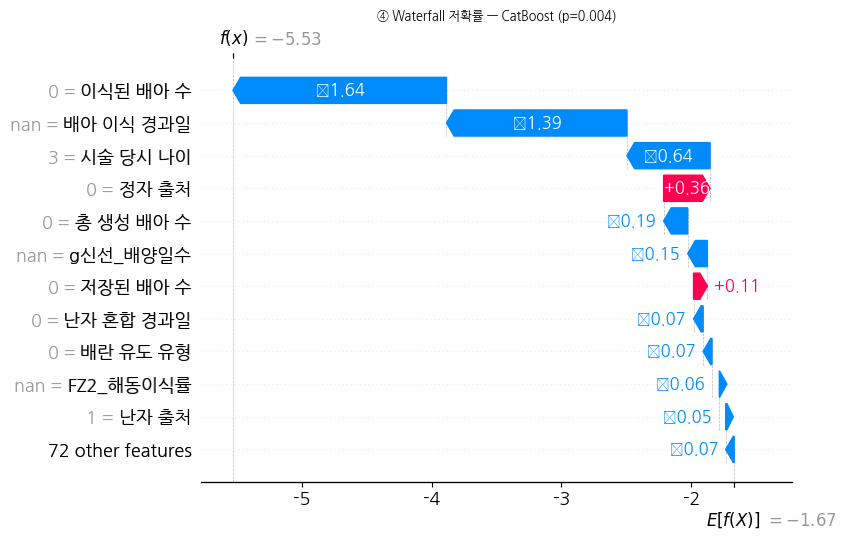

[저확률] v2피처 기여: {'LightGBM': {'g신선_수정률': np.float64(-0.088), 'g본인_난자수율': np.float64(-0.08), 'g신선_배양일수': np.float64(0.033)}, 'XGBoost': {'g신선_수정률': np.float32(-0.151), 'g본인_난자수율': np.float32(-0.12), 'g신선_배양일수': np.float32(-0.071)}, 'CatBoost': {'g신선_배양일수': np.float64(-0.152), 'FZ2_해동이식률': np.float64(-0.057), 'g신선_수정률': np.float64(-0.034)}}


In [9]:
try:
    assert SH; import shap
    ref=SH["lgb"]["proba"]; cases=[("고확률",int(np.argmax(ref))),("저확률",int(np.argmin(ref)))]
    for title,i in cases:
        for k in KINDS:
            e=shap.Explanation(values=SH[k]["sv"],base_values=np.full(len(Xs),SH[k]["base"]),data=Xs.values,feature_names=list(Xv2.columns))
            shap.plots.waterfall(e[i],max_display=12,show=False)
            fig=plt.gcf(); fig.set_size_inches(8.5,5.5); plt.title(f"④ Waterfall {title} — {KNAME[k]} (p={SH[k]['proba'][i]:.3f})",fontsize=9)
            plt.tight_layout(); plt.savefig(f"/kaggle/working/v2viz4_wf_{title[:2]}_{k}.png",dpi=105,bbox_inches="tight"); plt.show(); plt.close()
        print(f"[{title}] v2피처 기여:",{KNAME[k]:{c:round(pd.Series(SH[k]['sv'][i],index=Xv2.columns)[c],3) for c in pd.Series(SH[k]['sv'][i],index=Xv2.columns)[V2COLS].abs().sort_values(ascending=False).head(3).index} for k in KINDS})
except Exception as e: print("⚠️ waterfall skip:",type(e).__name__,e)

## 9. 임상 — 게이팅 비율 성공률 by 구간 (모달리티 내부 신호)

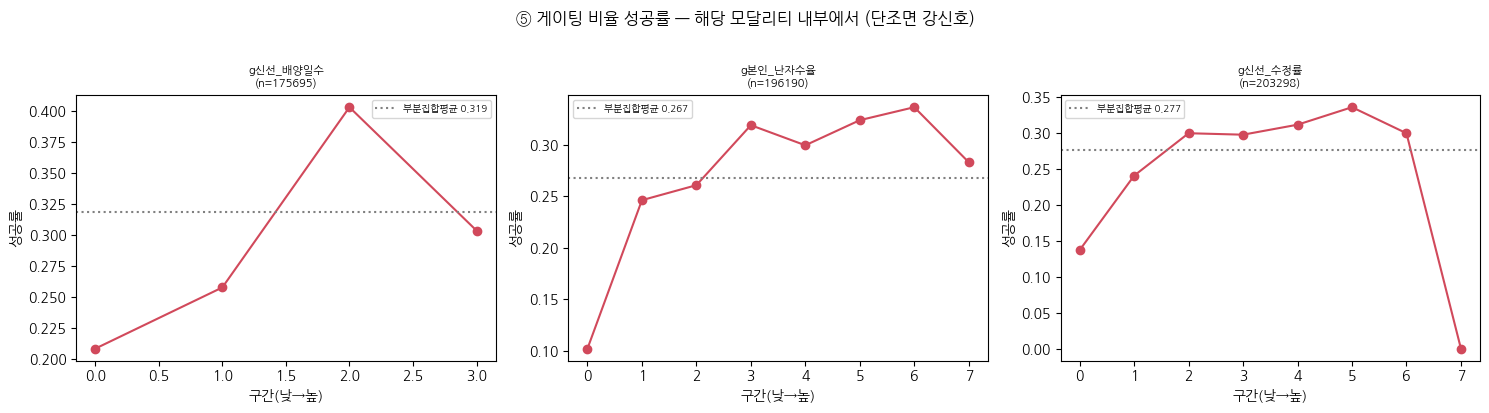

In [10]:
try:
    gated=[c for c in V2.columns if c.startswith("g") or c.startswith("FZ")]
    # 결측 적고 고유값 충분한 게이팅 비율 top3
    cand=[c for c in gated if V2[c].notna().sum()>200 and V2[c].nunique()>5]
    cand=sorted(cand,key=lambda c:-abs(np.corrcoef(V2[c].fillna(V2[c].median()),y)[0,1]))[:3]
    fig,axes=plt.subplots(1,len(cand),figsize=(5*len(cand),4))
    if len(cand)==1: axes=[axes]
    for ax,c in zip(axes,cand):
        v=V2[c]; ok=v.notna()
        try: b=pd.qcut(v[ok],8,duplicates="drop")
        except: b=pd.cut(v[ok],8)
        g=pd.DataFrame({"b":b,"yy":y[ok.values]}).groupby("b",observed=True)["yy"].agg(["mean","size"])
        ax.plot(range(len(g)),g["mean"].values,"o-",color="#d1495b")
        ax.axhline(y[ok.values].mean(),color="gray",ls=":",label=f"부분집합평균 {y[ok.values].mean():.3f}")
        ax.set_title(f"{c}\n(n={int(ok.sum())})",fontsize=8); ax.set_ylabel("성공률"); ax.set_xlabel("구간(낮→높)"); ax.legend(fontsize=7)
    plt.suptitle("⑤ 게이팅 비율 성공률 — 해당 모달리티 내부에서 (단조면 강신호)",y=1.02)
    plt.tight_layout(); plt.savefig("/kaggle/working/v2viz5_clinical.png",dpi=110,bbox_inches="tight"); plt.show()
except Exception as e: print("⚠️ clinical skip:",type(e).__name__,e)